# Autocomplete and Autocorrect Data Analytics

**Corpus:** NLTK's Project Gutenberg corpus (public-domain classic literature: Jane Austen, Shakespeare,
Melville, etc.) — a large, freely available English text corpus, bundled with NLTK.
**Goal:** Build and evaluate a frequency-based n-gram autocomplete model and an edit-distance-based
autocorrect model, then compare each against an alternative approach.

In [1]:
import nltk
import re
import string
from collections import Counter, defaultdict
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from spellchecker import SpellChecker
import os

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.figsize"] = (10, 6)

nltk.download("gutenberg", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

## 1. Load and preprocess the corpus

In [2]:
from nltk.corpus import gutenberg

raw_text = " ".join(gutenberg.raw(fid) for fid in gutenberg.fileids())
print("Total characters:", len(raw_text))
print("Files used:", gutenberg.fileids())

Total characters: 11793335
Files used: ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [3]:
def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]  # drop punctuation/numbers
    return tokens

tokens = preprocess(raw_text)
print("Total tokens:", len(tokens))
print("Sample:", tokens[:15])

Total tokens: 2095447
Sample: ['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', 'handsome', 'clever', 'and', 'rich', 'with']


## 2. Word frequency analysis

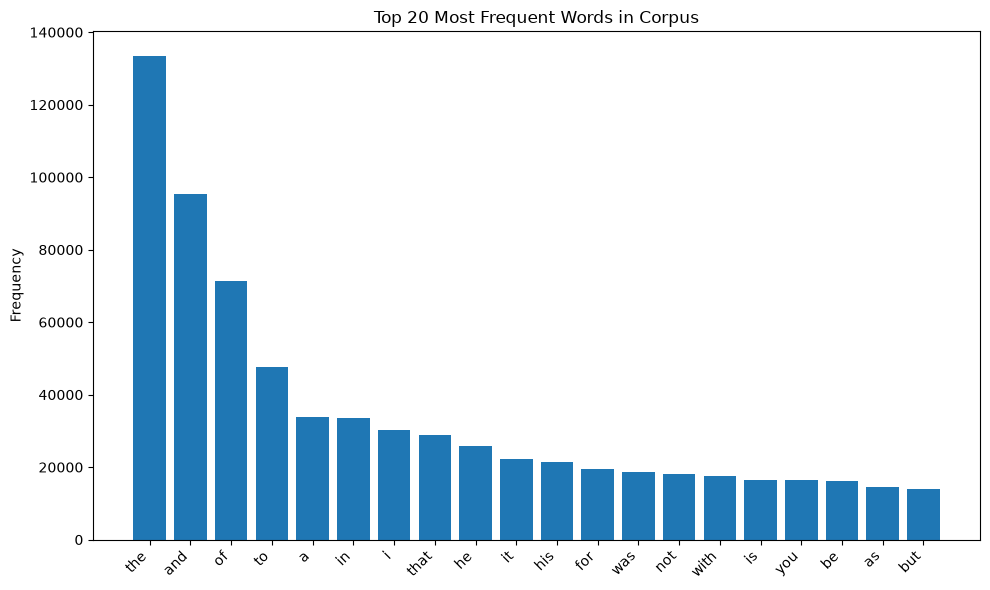

In [4]:
word_freq = Counter(tokens)
top20 = word_freq.most_common(20)

words, counts = zip(*top20)
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words in Corpus")
plt.tight_layout()
plt.savefig("outputs/01_top20_words.png")
plt.show()

## 3. Autocomplete: frequency-based n-gram model

We build bigram and trigram frequency tables from the corpus. Given a prefix (the last 1-2 words typed),
the model looks up which words most often followed that prefix in the corpus, and returns the top 3
candidates ranked by frequency.

In [5]:
bigrams = list(nltk.bigrams(tokens))
trigrams = list(nltk.trigrams(tokens))

bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

# next-word lookup tables
bigram_next = defaultdict(Counter)
for (w1, w2), c in bigram_freq.items():
    bigram_next[w1][w2] += c

trigram_next = defaultdict(Counter)
for (w1, w2, w3), c in trigram_freq.items():
    trigram_next[(w1, w2)][w3] += c

def autocomplete(prefix_words, top_n=3):
    prefix_words = [w.lower() for w in prefix_words]
    if len(prefix_words) >= 2 and tuple(prefix_words[-2:]) in trigram_next:
        candidates = trigram_next[tuple(prefix_words[-2:])]
    elif prefix_words and prefix_words[-1] in bigram_next:
        candidates = bigram_next[prefix_words[-1]]
    else:
        return []
    return [w for w, _ in candidates.most_common(top_n)]

In [6]:
test_prefixes = [
    ["i", "am"], ["it", "is"], ["she", "said"], ["he", "was"], ["in", "the"],
    ["to", "be"], ["there", "is"], ["you", "are"], ["we", "shall"], ["my", "dear"],
]

autocomplete_results = []
for prefix in test_prefixes:
    preds = autocomplete(prefix, top_n=3)
    autocomplete_results.append({"prefix": " ".join(prefix), "top_3_predictions": ", ".join(preds)})

autocomplete_df = pd.DataFrame(autocomplete_results)
autocomplete_df.to_csv("outputs/autocomplete_results.csv", index=False)
autocomplete_df

,prefix,top_3_predictions
0,i am,"sure, the, not"
1,it is,"a, not, the"
2,she said,"to, unto, i"
3,he was,"a, not, in"
4,in the,"land, midst, world"
5,to be,"sure, a, the"
6,there is,"no, a, none"
7,you are,"not, a, very"
8,we shall,"be, have, not"
9,my dear,"i, emma, sir"


## 4. Autocorrect: edit-distance based correction

Two approaches are compared:
1. **pyspellchecker** — a frequency-informed Levenshtein-distance spell checker (industry-style approach,
   candidates ranked by corpus word frequency).
2. **Custom Levenshtein nearest-neighbor** — for each misspelled word, we compute edit distance to every
   word in our own corpus vocabulary and pick the closest match, ranked purely by distance (no frequency
   weighting) — this isolates how much frequency information actually helps.

In [7]:
vocab = set(word_freq.keys())
spell = SpellChecker()
spell.word_frequency.load_words(vocab)  # bias the checker toward our corpus vocabulary

def levenshtein(a, b):
    if len(a) < len(b):
        return levenshtein(b, a)
    if len(b) == 0:
        return len(a)
    previous_row = range(len(b) + 1)
    for i, ca in enumerate(a):
        current_row = [i + 1]
        for j, cb in enumerate(b):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (ca != cb)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

def custom_autocorrect(word, vocab_list):
    if word in vocab:
        return word
    # narrow search to words of similar length for tractable runtime
    candidates = [v for v in vocab_list if abs(len(v) - len(word)) <= 2]
    best = min(candidates, key=lambda v: levenshtein(word, v))
    return best

In [8]:
# 20 deliberately misspelled words, with their intended correct spelling.
# NOTE: words like "untill", "frend", "comming", "truely" were deliberately excluded even
# though they are common modern misspellings -- they are archaic-but-valid spelling variants
# that actually occur in this 19th-century Gutenberg corpus (e.g. "comming" appears 13 times),
# so both correction methods would "correctly" (from the corpus's perspective) leave them
# unchanged, contaminating the accuracy comparison. Verified absent from corpus vocabulary below.
misspelled_words = [
    ("teh", "the"), ("recieve", "receive"), ("wich", "which"), ("thier", "their"),
    ("beleive", "believe"), ("seperate", "separate"), ("definately", "definitely"),
    ("occured", "occurred"), ("wensday", "wednesday"), ("wenever", "whenever"),
    ("adress", "address"), ("happyness", "happiness"), ("goverment", "government"),
    ("langage", "language"), ("knowlege", "knowledge"), ("bussiness", "business"),
    ("acomodate", "accommodate"), ("familys", "families"), ("childs", "children"),
    ("beutiful", "beautiful"),
]

for _w, _ in misspelled_words:
    assert _w not in vocab, f"{_w!r} unexpectedly already in corpus vocabulary"

vocab_list = sorted(vocab)  # deterministic order so distance ties break the same way on every run
autocorrect_results = []
for wrong, correct in misspelled_words:
    spell_pred = spell.correction(wrong) or wrong
    custom_pred = custom_autocorrect(wrong, vocab_list)
    autocorrect_results.append({
        "misspelled": wrong,
        "intended": correct,
        "pyspellchecker": spell_pred,
        "pyspellchecker_correct": spell_pred == correct,
        "custom_levenshtein": custom_pred,
        "custom_correct": custom_pred == correct,
    })

autocorrect_df = pd.DataFrame(autocorrect_results)
autocorrect_df.to_csv("outputs/autocorrect_results.csv", index=False)
autocorrect_df

,misspelled,intended,pyspellchecker,pyspellchecker_correct,custom_levenshtein,custom_correct
0,teh,the,the,True,eh,False
1,recieve,receive,receive,True,relieve,False
2,wich,which,with,False,rich,False
3,thier,their,their,True,ther,False
4,beleive,believe,believe,True,baleine,False
5,seperate,separate,separate,True,separate,True
6,definately,definitely,definitely,True,definitely,True
7,occured,occurred,occurred,True,occurred,True
8,wensday,wednesday,wendy,False,wednesday,True
9,wenever,whenever,whenever,True,whenever,True


## 5. Performance metrics

In [9]:
spell_accuracy = autocorrect_df["pyspellchecker_correct"].mean()
custom_accuracy = autocorrect_df["custom_correct"].mean()

print(f"pyspellchecker accuracy: {spell_accuracy:.1%}")
print(f"Custom Levenshtein accuracy: {custom_accuracy:.1%}")

metrics_summary = pd.DataFrame({
    "Method": ["pyspellchecker", "Custom Levenshtein"],
    "Accuracy": [spell_accuracy, custom_accuracy],
})
metrics_summary.to_csv("outputs/autocorrect_metrics.csv", index=False)
metrics_summary

pyspellchecker accuracy: 75.0%
Custom Levenshtein accuracy: 65.0%


,Method,Accuracy
0,pyspellchecker,0.75
1,Custom Levenshtein,0.65


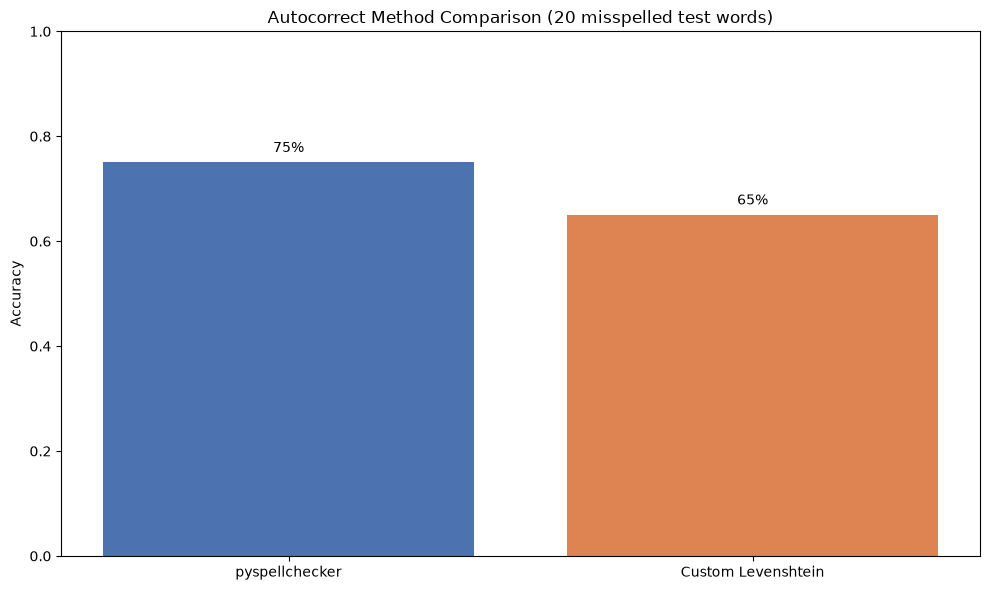

In [10]:
plt.bar(metrics_summary["Method"], metrics_summary["Accuracy"], color=["#4C72B0", "#DD8452"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Autocorrect Method Comparison (20 misspelled test words)")
for i, v in enumerate(metrics_summary["Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.savefig("outputs/02_autocorrect_comparison.png")
plt.show()

## 6. Discussion: limitations vs. production systems

This project demonstrates the core *mechanisms* behind autocomplete and autocorrect, but production
systems like Google Keyboard or iOS predictive text differ in several important ways:

- **Personalization:** production systems adapt to an individual user's vocabulary and writing style over
  time; this model is a single static frequency table trained once on a fixed corpus.
- **Context window:** our n-gram model only looks 1-2 words back. Production systems use much larger
  context (often whole sentences) via neural language models (transformers), capturing long-range
  dependencies our simple frequency table cannot.
- **Keyboard-layout awareness:** real autocorrect also weighs *physical* key proximity (a "g" typo for "h"
  is likely a keyboard slip, not a phonetic error) — our Levenshtein-only approach treats all substitutions
  equally.
- **Corpus mismatch:** our corpus is 19th-century literary English (Project Gutenberg), which explains any
  predictions that read "old-fashioned" — a production system trained on contemporary text/chat data would
  predict differently for the same prefix.
- **Speed at scale:** the custom Levenshtein approach searches the *entire* vocabulary per word, which does
  not scale to production traffic; pyspellchecker's frequency-pruned candidate generation is the more
  realistic simplification of what production systems actually do (e.g., using a BK-tree or trie for
  fast approximate lookups).